In [1]:
%matplotlib inline

## DL - ASSIGNMENT -2

# IMAGE CAPTIONING

### GROUP - 123


#### SANTHOSH M -  2019AB04197

### IMPORTING LIBRARIES

In [2]:
import pickle
import torch
import torch.nn as nn
import torchvision.models as models
import os
import pandas as pd
from nltk.tokenize import word_tokenize #for Tokenizer
from torch.nn.utils.rnn import pad_sequence # pad batch
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import math
import time
torch.cuda.is_available()

True

## CHECKING AVAILABLE GPU

In [110]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda

NVIDIA GeForce GTX 1660 Ti
Memory Usage:
Allocated: 0.5 GB
Cached:    1.2 GB


In [109]:
torch.cuda.empty_cache()

## FUNCTION FOR BUILDING VOCABULARY

In [6]:
class Vocabulary:
    def __init__(self,freq_threshold):
        self.itos={0:'<PAD>',1:'<SOS>',2:'<EOS>',3:'<UNK>'}
        self.stoi={'<PAD>':0,'<SOS>':1,'<EOS>':2,'<UNK>':3}
        self.freq_threshold=freq_threshold
        self.max_length=0
    def __len__(self):
        return len(self.itos)
    @staticmethod
    def tokenizer_eng(text):
        return [tok.lower() for tok in word_tokenize(text.lower())]
    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        
        for sentence in sentence_list:
            if self.max_length<len(self.tokenizer_eng(sentence)):
                self.max_length=len(self.tokenizer_eng(sentence))
                
            for word in self.tokenizer_eng(sentence):                
                if word not in frequencies:
                    frequencies[word] = 1

                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
        
    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        stoi_list= [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]
        stoi_list=[self.stoi['<SOS>']]+stoi_list
        stoi_list.append(self.stoi['<EOS>'])
        #pADDING ALL SENTENCED TO EQUAL LENGTH
        for i in range (self.max_length - len(stoi_list)+2): 
            stoi_list.append(self.stoi['<PAD>'])
        return stoi_list

## DATASET FUNCTION

In [7]:
class Flickr8k_Dataset(Dataset):
    def __init__(self,Image_dir,caption_file,freq_threshold=1,transform=None): #,tranform=None
        self.root_dir=Image_dir
        self.transform = transform
        
        self.df = pickle.load(open(caption_file,'rb'))
        self.df=pd.DataFrame(self.df,columns=["Image_Details"])
        self.df[['Image_description','Caption']] = self.df.Image_Details.str.split("\t",expand=True)
        self.df[['Image','Caption_id']] = self.df.Image_description.str.split("#",expand=True)
        self.df = self.df[['Image','Caption_id','Caption']]
        
        for i in range(len(self.df)):
            if not  self.df.loc[i,'Image'].endswith('.jpg'):
                self.df=self.df.drop(i)
        self.df=self.df.reset_index()
        self.imgs=self.df['Image']
        self.captions=self.df['Caption']
        self.vocab=Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())
    def __len__(self):
        return len(self.df)
    def __getitem__(self,index):
        caption=self.captions[index]
        img_id=self.imgs[index]
        img=Image.open(os.path.join(self.root_dir,img_id)).convert('RGB')
        if self.transform is not None:
            img=self.transform(img)
        
        numericalized_caption = self.vocab.numericalize(caption)
        
        return img, torch.tensor(numericalized_caption).to(device) 
        

## DATA LOADER FUNCTION

In [9]:
def get_loader(
    root_folder,
    annotation_file,
    transform,
    batch_size=32,
    num_workers=0,
    shuffle=True,
    pin_memory=False,
    freq_threshold=1
):
    dataset = Flickr8k_Dataset(root_folder, annotation_file,transform=transform,freq_threshold=freq_threshold )
    
    # Splitting Into TRAIN and TEST Data (90-10)
    u=int(0.9*len(dataset))
    v=len(dataset)-u
    trainset, validset=random_split(dataset,[u,v])
    pad_idx = dataset.vocab.stoi["<PAD>"]

    Trainloader = DataLoader(
        dataset=trainset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
    
    )
    Validloader = DataLoader(
        dataset=validset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        
    )

    return Trainloader,Validloader,dataset


In [10]:
transform = transforms.Compose(
        [ transforms.ToTensor(),transforms.Resize((224, 224)),]#transforms.Resize((224, 224)),
    )

_,yo, dataset = get_loader(
    "D:/WILP/SEMESTER_3/DL/Assignments-2/Image_captioning_Dataset/Flicker8k_Dataset/",
    "set_3.pkl",
    transform=transform,
    )

## PLOTTING SAMPLE IMAGE WITH CAPTION

<SOS> two white standard poodle play tug of war in the snow . <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> 


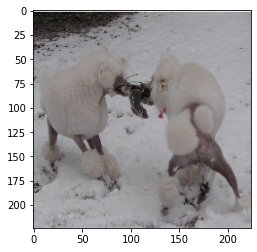

In [11]:
trans = transforms.ToPILImage()
rnd_idx=2021

plt.imshow(trans(dataset[rnd_idx][0]))
caption_str=''
for i in range(len(dataset[rnd_idx][1])):
    caption_str+=dataset.vocab.itos[dataset[rnd_idx][1].tolist()[i]]
    caption_str+=' '
print(caption_str)    

## ENCODER CNN - VGG16

In [111]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size,num_layers, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.vgg16 = models.vgg16(pretrained=True)
        
        #MODIFYING THE LAST LAYER OF THE CNN TO MATCH THE HIDDEN DIMENSION OF THE RNN
        self.vgg16.classifier[6] = nn.Linear(self.vgg16.classifier[6].in_features, embed_size*num_layers)
        self.relu = nn.ReLU()
        self.times = []
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        images=images
        features = self.vgg16(images)
        return self.dropout(self.relu(features))


## DECODER RNN - 3 LAYER  GRU

In [14]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.GRU = nn.GRU(embed_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, In_, Hidden):
        Inpt = In_.unsqueeze(0)
        embeddings=self.dropout(self.embed(Inpt))
        output, Hidden = self.GRU(embeddings,Hidden)
        Prediction = self.linear(output.squeeze(0))
        return Prediction,Hidden


## CNN TO RNN (IMAGE CAPTIONING MODEL)

In [15]:
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers,max_length,batch_size,sos_tok):
        super(CNNtoRNN, self).__init__()
        self.max_length=max_length
        self.num_layers=num_layers
        self.hidden_size=hidden_size
        self.vocab_size=vocab_size
        self.batch_size=batch_size
        self.embed_size=embed_size
        self.sos_tok=sos_tok
        self.encoderCNN = EncoderCNN(embed_size,num_layers)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images,device,captions = None):#, captions
        # THE FEATURES EXTRACTED FROM VGG 16 WILL BE USED AS HIDDEN LAYER FOR THE GRU
        hidden = self.encoderCNN(images)
        BS=hidden.shape[0]
        hidden=hidden.reshape(self.num_layers,BS,self.hidden_size).to(device)
        
        
        
        # THE FIRST INPUT FOR GRU IS SET TO <SOS> (START OF SENTENCE)
        Inp=[self.sos_tok for i in range(BS)]
        Inp = torch.tensor(Inp).long().to(device)
        
        #OUTPUTS ARE INITIATED AS A ZEROS TENSOR WITH THE FIRST WORD SET TO <SOS> 
        Outputs=torch.zeros(self.max_length+2, BS, self.vocab_size).to(device)        
        for i in range(BS):
            Outputs[0][i][self.sos_tok]=1
            
            
        
        for i in range(1,(self.max_length+2)):
            Inp=Inp.long()
            hidden=hidden.float()
            output,hidden=self.decoderRNN(Inp,hidden)
            Outputs[i]=output
                       
            top1=output.argmax(1)
            if captions!= None:
                
                Inp = torch.transpose(captions,0,1)[i].to(device)
            else:
                Inp=top1         
        
        return Outputs

    

In [16]:
from tqdm import tqdm
import torch.optim as optim



transform = transforms.Compose(
    [
        transforms.Resize((356, 356)),
        transforms.RandomCrop((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
batch_size=32

train_loader,valid_loader, dataset = get_loader(

    root_folder="D:/WILP/SEMESTER_3/DL/Assignments-2/Image_captioning_Dataset/Flicker8k_Dataset/",
    annotation_file="set_3.pkl",
    transform=transform,
    num_workers=0,
    batch_size=batch_size,
    freq_threshold=5
)

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Hyperparameters
embed_size = 256
hidden_size = 256
vocab_size = len(dataset.vocab)
max_length=dataset.vocab.max_length

sos_tok=dataset.vocab.stoi['<SOS>']
num_layers = 3 # NUMBER OF LAYERS IN GRU
learning_rate = 3e-3 # LEARNIING RATE
num_epochs = 7 # NUMBER OF EPOCHS


#step = 0

# initialize model, loss etc
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers,max_length,batch_size,sos_tok).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.vocab.stoi["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_CNN=False
# SETTING THE LAST LAYER OF THE VGG 16 TO BE TRAINABLE
for name, param in model.encoderCNN.vgg16.named_parameters():
    if "Classifier.6.weight" in name or "classifier.6.bias" in name:
        param.requires_grad = True
    else:
        param.requires_grad = train_CNN

## MODEL  SUMMARY

In [17]:
print(model)

CNNtoRNN(
  (encoderCNN): EncoderCNN(
    (vgg16): VGG(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (6): ReLU(inplace=True)
        (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (8): ReLU(inplace=True)
        (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (11): ReLU(inplace=True)
        (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (13): ReLU(inplace=True)
        (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 

In [18]:
#INITIALISING THE MODEL WITH RANDOM WEIGHTS WITH UNIFORM DISTRIBUTION IN THE RANGE (-0.08,0.08)
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
        
model.apply(init_weights)

CNNtoRNN(
  (encoderCNN): EncoderCNN(
    (vgg16): VGG(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (6): ReLU(inplace=True)
        (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (8): ReLU(inplace=True)
        (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (11): ReLU(inplace=True)
        (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (13): ReLU(inplace=True)
        (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 

In [19]:
# THE NUMBER OF TRAINABLE PARAMETERS
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 2,123,814 trainable parameters


## TRAIN FUNCTION

In [20]:
def train(model, iterator, optimizer, criterion):    
    model.train()    
    epoch_loss = 0    
    for idx, (imgs, captions) in tqdm(
        enumerate(iterator), total=len(iterator), leave=False
    ):       
        imgs=imgs.to(device)
        captions = captions.to(device)
        
        output = model(imgs,device,captions).to(device)        
        optimizer.zero_grad()        
               
        #trg = [trg len, batch size]
        #output = [trg len, batch size, output dim]
        
        output_dim = output.shape[-1] 

        output = output[1:].view(-1, output_dim)
        captions=torch.transpose(captions,1,0)
        captions= captions[1:].reshape(-1)
        
        #trg = [(trg len - 1) * batch size]
        #output = [(trg len - 1) * batch size, output dim]
        
        loss = criterion(output,captions)        
        loss.backward()        
        #torch.nn.utils.clip_grad_norm_(model.parameters(), clip)        
        optimizer.step()        
        epoch_loss += loss.item()        
    return epoch_loss / len(iterator)

## EVALUATION FUNCTION

In [21]:
def evaluate(model, iterator, optimizer, criterion, clip):    
    model.eval()    
    epoch_loss = 0    
    for idx, (imgs, captions) in tqdm(
        enumerate(iterator), total=len(iterator), leave=False
    ):       
        imgs=imgs.to(device)
        captions = captions.to(device)
        output = model(imgs,device,captions)      
        optimizer.zero_grad()        
               
        #trg = [trg len, batch size]
        #output = [trg len, batch size, output dim]
        
        output_dim = output.shape[-1]        
        output = output[1:].view(-1, output_dim)
        captions=torch.transpose(captions,1,0)
        captions= captions[1:].reshape(-1)
        
        #trg = [(trg len - 1) * batch size]
        #output = [(trg len - 1) * batch size, output dim]
        
        loss = criterion(output,captions)        
        
        epoch_loss += loss.item()        
    return epoch_loss / len(iterator)

In [22]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

## MODEL TRAINING

In [23]:

TL=[]
VL=[]

for epoch in range(num_epochs):
    
    start_time = time.time()
    train_loss = train(model, train_loader, optimizer, criterion)
    valid_loss = train(model, valid_loader, optimizer, criterion)
    TL.append(train_loss)
    VL.append(valid_loss)
    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} ')
    print(f'\t Val. Loss: {valid_loss:.3f} ')
    

  0%|                                                                                          | 0/703 [00:00<?, ?it/s]C:\ProgramData\Anaconda3\envs\pytorch_env\lib\site-packages\torch\nn\functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  ..\c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Epoch: 01 | Time: 11m 0s
	Train Loss: 1121.124 
	 Val. Loss: 712.162 


Epoch: 02 | Time: 8m 36s
	Train Loss: 591.211 
	 Val. Loss: 445.687 


Epoch: 03 | Time: 8m 38s
	Train Loss: 365.870 
	 Val. Loss: 327.492 


Epoch: 04 | Time: 8m 37s
	Train Loss: 244.708 
	 Val. Loss: 203.387 


Epoch: 05 | Time: 8m 36s
	Train Loss: 162.631 
	 Val. Loss: 121.518 


Epoch: 06 | Time: 8m 37s
	Train Loss: 113.718 
	 Val. Loss: 85.973 


Epoch: 07 | Time: 8m 31s
	Train Loss: 87.035 
	 Val. Loss: 91.285 


<function matplotlib.pyplot.show(close=None, block=None)>

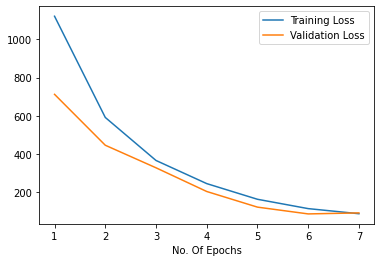

In [117]:
plt.plot([i+1 for i in range(num_epochs)],TL, label='Training Loss')
plt.plot([i+1 for i  in range(num_epochs)],VL, label='Validation Loss')
plt.xlabel('No. Of Epochs')
plt.legend()
plt.show

## PREDICTING CAPTION FOR A RANDOM GOOGLE IMAGE

In [102]:
model.eval()
#LOADING IMAGE
Google_image1=Image.open('gimage.jpg').convert('RGB')
transform = transforms.Compose(
    [
        transforms.Resize((356, 356)),
        transforms.RandomCrop((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
Google_image=transform(Google_image1)
Google_image=Google_image.unsqueeze(0).to(device)

In [103]:
out=model(images=Google_image,device=device)

In [104]:
Generated_caption=''

for i in range(max_length+2):
    Generated_caption+= dataset.vocab.itos[out[i].argmax(1).item()] + ' '
    
    
    

<SOS> a brown a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a 


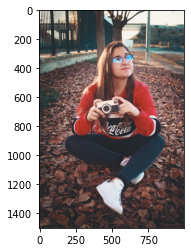

In [105]:
plt.imshow(Google_image1)
print(Generated_caption)

#### THE BAD PERFORMANCE OF THE MODEL IS DUE TO LOW NO. OF TRAINING EPOCHS DUE TO THE USE OF COMMODITY HARWARE.